# Composite heat fluxes during MHW events
# SPEAR-LO

In [1]:
import xarray as xr
import pandas as pd
import json
import numpy as np
import cmocean
import cartopy.crs as ccrs #cartopy coord ref sys
import cartopy
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm
from matplotlib.colors import ListedColormap
import time
from tqdm import tqdm
import glob
import os
from collections import defaultdict
import xesmf as xe
import ast #for parsing through events_by_cell.json file

In [38]:
def load_hf_ensemble(hf_var, ps, pe):
    """
    Load heat fluxes individually with SPEAR-HI25 ensemble members concatonated into a single ds for each flux
    """
    formatted_list = [str(i).zfill(2) for i in range(1, 31)]
    ds1 = xr.open_mfdataset([f'/work/stb/MHW-gfdl/SPEAR/SPEAR_c384_OM4p25_Hist_SSP245_IC1991_R61_ens_{ens_num}/{hf_var}_ens{ens_num}_1991-2100.nc' for ens_num in formatted_list], 
                            chunks={}, decode_timedelta=True, concat_dim='ensemble', combine='nested')
    time_period = dict(time=slice(ps, pe))
    ds = ds1.sel(lat=slice(10, 31), lon=slice(262,344), 
                 **time_period).assign_coords(ensemble=[int(e) for e in formatted_list])

    return ds

## SPEAR-HI25 (1991-2024)

Var names to download:
- lwflx
- shflx
- swup_sfc
- swdn_sfc
- evap 

In [30]:
2100-1991

109

In [31]:
110*365

40150

In [32]:
40150-38350

1800

In [35]:
lwflx_9124 = load_hf_ensemble('lwflx', '1991', '2024')


FileNotFoundError: [Errno 2] No such file or directory: '/work/stb/MHW-gfdl/SPEAR/SPEAR_c384_OM4p25_Hist_SSP245_IC1991_R61_ens_11/lwflx_ens11_1991-2100.nc'

In [ ]:
lwflx_ds

### Open heat fluxes

In [20]:
lwflx_ds = load_hf_ensemble('lwflx')
swdn_sfc = load_hf_ensemble('swdn_sfc')
swup_sfc = load_hf_ensemble('swup_sfc')
swflx_ds = swdn_sfc - swup_sfc
evap_ds = load_hf_ensemble('evap')
shflx_ds = load_hf_ensemble('shflx')
evap_ds

<xarray.Dataset> Size: 161GB
Dimensions:     (ensemble: 30, time: 38350, lat: 124, lon: 282, bnds: 2)
Coordinates:
  * ensemble    (ensemble) int64 240B 1 2 3 4 5 6 7 8 ... 24 25 26 27 28 29 30
  * time        (time) object 307kB 1991-01-01 12:00:00 ... 2100-12-31 12:00:00
  * lat         (lat) float64 992B 0.125 0.375 0.625 0.875 ... 30.38 30.63 30.88
  * lon         (lon) float64 2kB 262.0 262.3 262.7 263.0 ... 349.2 349.5 349.8
  * bnds        (bnds) float64 16B 1.0 2.0
Data variables:
    average_DT  (ensemble, time) timedelta64[ns] 9MB dask.array<chunksize=(1, 38350), meta=np.ndarray>
    average_T1  (ensemble, time) datetime64[ns] 9MB dask.array<chunksize=(1, 38350), meta=np.ndarray>
    average_T2  (ensemble, time) datetime64[ns] 9MB dask.array<chunksize=(1, 38350), meta=np.ndarray>
    evap        (ensemble, time, lat, lon) float32 161GB dask.array<chunksize=(1, 38350, 124, 282), meta=np.ndarray>
    lat_bnds    (ensemble, lat, bnds) float64 60kB dask.array<chunksize=(1, 124, 2), meta=np.ndarray>
    lon_bnds    (ensemble, lon, bnds) float64 135kB dask.array<chunksize=(1, 282, 2), meta=np.ndarray>
    time_bnds   (ensemble, time, bnds) object 18MB dask.array<chunksize=(1, 38350, 2), meta=np.ndarray>
Attributes:
    title:                 SPEAR_c384_OM4p25_Hist_SSP245_IC1991_R61_ens_01
    grid_type:             regular
    grid_tile:             N/A
    code_release_version:  2023.01.02
    git_hash:              8176c2b45079431f2053ec773253938f8aee4828
    creationtime:          Fri May  3 02:26:29 2024
    hostname:              pp338
    history:               Thu Apr 16 18:22:59 2026: ncrcat evap_ens01_1991.n...
    NCO:                   netCDF Operators version 5.2.4 (Homepage = http://...

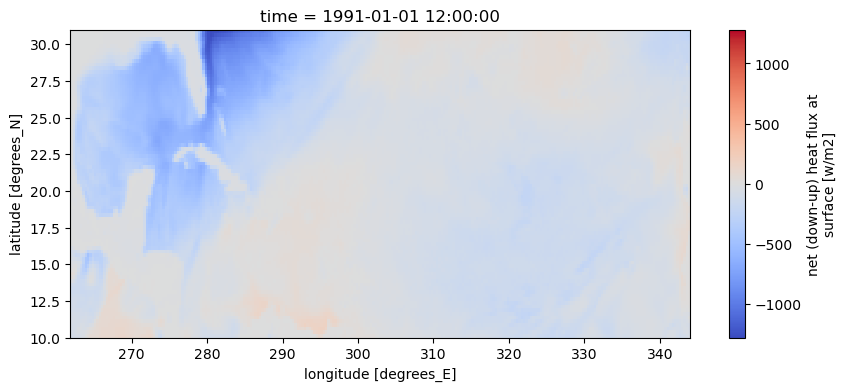

In [17]:
carib[0].plot(figsize=(10,4), cmap='coolwarm')

### Open event masks

In [66]:
formatted_list = [str(i).zfill(2) for i in range(1,31)]
event_mask9124_lds = [] #list of the ds'
for ens_num in tqdm(formatted_list):
    event_mask9124_lds.append(xr.open_mfdataset(f'/work/stb/MHW-gfdl/SPEAR/vars/SPEAR-HI25/period_1991-2024/events/event_mask_sphi{ens_num}.nc',
                                     decode_timedelta=True).rename_vars({'__xarray_dataarray_variable__': 'event_mask'}))
    time.sleep(0.01)

100%|██████████| 30/30 [00:02<00:00, 12.29it/s]


In [67]:
event_mask9124_lds

[<xarray.Dataset> Size: 364MB
 Dimensions:     (time: 12419, yT: 90, xT: 325)
 Coordinates:
   * time        (time) object 99kB 1991-01-01 12:00:00 ... 2024-12-31 12:00:00
     month       (time) int64 99kB dask.array<chunksize=(12419,), meta=np.ndarray>
     dayofyear   (time) int64 99kB dask.array<chunksize=(12419,), meta=np.ndarray>
   * yT          (yT) float64 720B 10.2 10.44 10.69 10.93 ... 30.46 30.67 30.89
   * xT          (xT) float64 3kB -97.84 -97.58 -97.33 ... -16.65 -16.4 -16.15
     quantile    float64 8B ...
 Data variables:
     event_mask  (time, yT, xT) bool 363MB dask.array<chunksize=(12419, 90, 325), meta=np.ndarray>,
 <xarray.Dataset> Size: 364MB
 Dimensions:     (time: 12419, yT: 90, xT: 325)
 Coordinates:
   * time        (time) object 99kB 1991-01-01 12:00:00 ... 2024-12-31 12:00:00
     month       (time) int64 99kB dask.array<chunksize=(12419,), meta=np.ndarray>
     dayofyear   (time) int64 99kB dask.array<chunksize=(12419,), meta=np.ndarray>
   * yT         

In [71]:
event_mask9124 = xr.concat(event_mask9124_lds, dim='ensemble').drop_vars(('month','dayofyear','quantile'))

In [72]:
event_mask9124

<xarray.Dataset> Size: 11GB
Dimensions:     (ensemble: 30, time: 12419, yT: 90, xT: 325)
Coordinates:
  * time        (time) object 99kB 1991-01-01 12:00:00 ... 2024-12-31 12:00:00
  * yT          (yT) float64 720B 10.2 10.44 10.69 10.93 ... 30.46 30.67 30.89
  * xT          (xT) float64 3kB -97.84 -97.58 -97.33 ... -16.65 -16.4 -16.15
Dimensions without coordinates: ensemble
Data variables:
    event_mask  (ensemble, time, yT, xT) bool 11GB dask.array<chunksize=(1, 12419, 90, 325), meta=np.ndarray>

In [73]:
event_mask9124.event_mask

<xarray.DataArray 'event_mask' (ensemble: 30, time: 12419, yT: 90, xT: 325)> Size: 11GB
dask.array<concatenate, shape=(30, 12419, 90, 325), dtype=bool, chunksize=(1, 12419, 90, 325), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 99kB 1991-01-01 12:00:00 ... 2024-12-31 12:00:00
  * yT       (yT) float64 720B 10.2 10.44 10.69 10.93 ... 30.46 30.67 30.89
  * xT       (xT) float64 3kB -97.84 -97.58 -97.33 ... -16.65 -16.4 -16.15
Dimensions without coordinates: ensemble

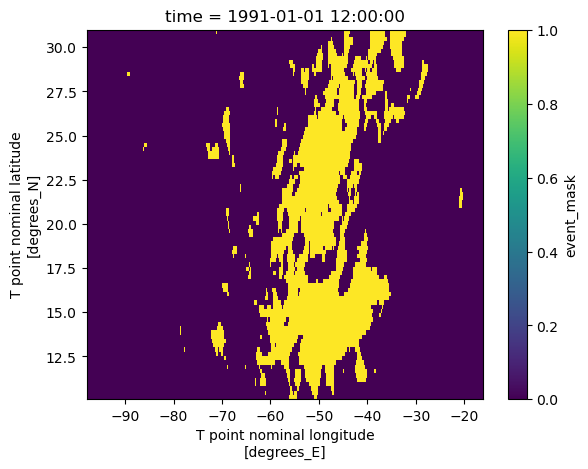

In [76]:
event_mask9124.event_mask.isel(ensemble=0)[0].plot()

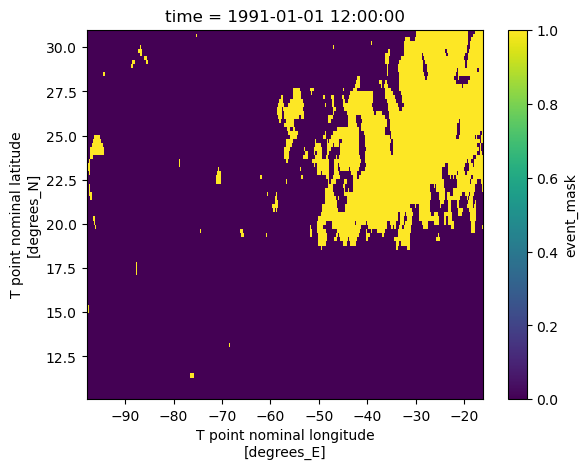

In [77]:
event_mask9124.event_mask.isel(ensemble=1)[0].plot()

In [31]:
def nrmse_std_norm(model, obs):
    """
    nRMSE normalized by spatial standard deviation of observations
    """
    rmse = np.sqrt(((model - obs) ** 2).mean())
    norm = obs.std()
    return rmse / norm

In [29]:
med_dur_200m = median_duration_ens_mean.where(mask)
freq_200m = frequency_ens_mean.drop_vars(('quantile','dayofyear','month', 'time')).where(mask)
int_200m = intensity_ens_mean.drop_vars('quantile').where(mask)

In [34]:
nrmse_freq_oi = nrmse_std_norm(freq_200m, freqo.where(mask)).values
nrmse_duration_oi = nrmse_std_norm(med_dur_200m, duro.where(mask)).values
nrmse_intensity_oi = nrmse_std_norm(int_200m, into.where(mask)).values

nrmse_freq_era = nrmse_std_norm(freq_200m, freqe.where(mask)).values
nrmse_duration_era = nrmse_std_norm(med_dur_200m, dure.where(mask)).values
nrmse_intensity_era = nrmse_std_norm(int_200m, inte.where(mask)).values

#nrmse_freq_oe = nrmse_std_norm(event_count_yearly_era.mean('time'), freq_ng_oe).values
#nrmse_duration_oe = nrmse_std_norm(median_duration_per_cell_era, med_dur_ng_oe).values
#nrmse_intensity_oe = nrmse_std_norm(mhw_intensity_yearly_era.mean('time'), int_ng_oe).values

In [38]:
nrmse_freq_oi

array(1.37157446)

In [39]:
nrmse_duration_oi

array(4.47572848)

In [40]:
nrmse_intensity_oi

array(1.00564824)

<p style="text-align: center;">nRMSE at 200m bathymetry</p>

| $\overline{S} - O$ | Freq | Duration | Intensity |
| --------- | -------| -------|  -------|
| OISST | 1.37 | 4.48 | 1.01 |
| ERA5 | 1.08 | 2.74 | 0.99 |
| ERA5/OISST | ? | ? | ? |

| nRMSE     | Meaning                                                         |
| --------- | --------------------------------------------------------------- |
| **< 0.5** | Model errors are small relative to observed spatial variability |
| **~ 1.0** | Model error equals typical observed spatial spread              |
| **1–2**   | Model errors large relative to real-world variability           |
| **> 2**   | Model performs poorly for this metric                           |
